This is the last notebook in which we will see the model, clustering and the visualisation of the clusters

In [ ]:
# we are going to use GPU for faster processing ( actually we use it from the start else it is going to take alot og time to run these huge files)
import torch
print("Torch:", torch.__version__)
print("CUDA build:", torch.version.cuda)          # should say 12.8
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Torch: 2.8.0+cu128
CUDA build: 12.8
CUDA available: True
GPU: NVIDIA RTX A4000


We import the libraries

And for clear and clean coding we put all the hyper parameter setting at one place so that it is easy 

Using device: cuda

Loading sampled segments and normalization stats...
Raw sample array shape: (540278, 8, 60)
Data normalized.
Tensor saved with shape: torch.Size([540278, 8, 60])
Total dataset size: 540278
Training samples: 432222, Validation samples: 108056

--- Training Setup ---
Device: cuda
Batch size: 64
Training batches: 6754, Validation batches: 1689
----------------------

No. of Epochs: 50
Starting training...

Epoch 01/50 | LR: 0.001000 | Train: 0.1335 (N/A) | Val: 0.1235 ✔ | Best: 0.1235 | Time: 33.39s | ETA: 0:27:15.908529
Epoch 02/50 | LR: 0.001000 | Train: 0.1264 (-5.3%) | Val: 0.1213 ✔ | Best: 0.1213 | Time: 31.64s | ETA: 0:25:18.922737
Epoch 03/50 | LR: 0.001000 | Train: 0.1240 (-1.9%) | Val: 0.1189 ✔ | Best: 0.1189 | Time: 31.85s | ETA: 0:24:57.138520
Epoch 04/50 | LR: 0.001000 | Train: 0.1155 (-6.8%) | Val: 0.1126 ✔ | Best: 0.1126 | Time: 31.07s | ETA: 0:23:49.344135
Epoch 05/50 | LR: 0.001000 | Train: 0.1020 (-11.7%) | Val: 0.0929 ✔ | Best: 0.0929 | Time: 31.42s |

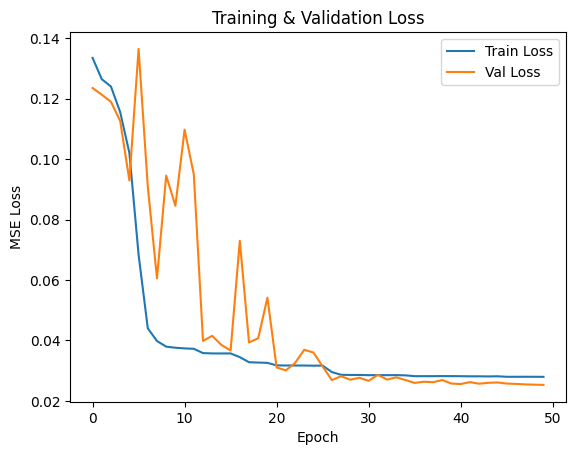


Extracting embeddings for all samples...
Saved embeddings: torch.Size([540278, 128])


In [5]:

import pickle
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from datetime import timedelta
import matplotlib.pyplot as plt

# =====================================================
# HYPERPARAMETERS
# =====================================================
BATCH_SIZE      = 64
LR              = 1e-3
WEIGHT_DECAY    = 1e-4
EPOCHS          = 50
PATIENCE        = 10
BOTTLENECK_DIM  = 128
TRAIN_SPLIT     = 0.8
SUBSET_SIZE     = 540278   # None = full dataset, int = random sample size
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}\n")

# =====================================================
# LOAD DATA
# =====================================================
print("Loading sampled segments and normalization stats...")

with open("bee_samples_with_ids.pkl", "rb") as f:
    data_dict = pickle.load(f)
sampled_segments = np.stack(data_dict["segments"], axis=0)  # (N, 8, 60)
print(f"Raw sample array shape: {sampled_segments.shape}")

with open("bee_norm_stats.pkl", "rb") as f:
    norm_stats = pickle.load(f)
means = norm_stats["mean"]
stds  = norm_stats["std"]

# Normalization
samples_array = (sampled_segments - means[:, None]) / stds[:, None]
print("Data normalized.")

tensor_data = torch.tensor(samples_array, dtype=torch.float32)
print(f"Tensor saved with shape: {tensor_data.shape}")

# Optional subset sampling
if SUBSET_SIZE is not None:
    idx = torch.randperm(tensor_data.size(0))[:SUBSET_SIZE]
    tensor_data = tensor_data[idx]

# =====================================================
# DATASET & SPLIT
# =====================================================
class BeeTrajectoryDataset(Dataset):
    def __init__(self, data_tensor):
        self.data = data_tensor
    def __len__(self):
        return self.data.shape[0]
    def __getitem__(self, idx):
        return self.data[idx]

full_dataset = BeeTrajectoryDataset(tensor_data)
train_size   = int(len(full_dataset) * TRAIN_SPLIT)
val_size     = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

print(f"Total dataset size: {len(full_dataset)}")
print(f"Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}\n")

print("--- Training Setup ---")
print(f"Device: {DEVICE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Training batches: {len(train_loader)}, Validation batches: {len(val_loader)}")
print("----------------------\n")

# =====================================================
# MODEL DEFINITION
# =====================================================
class BeeAutoencoder(nn.Module):
    def __init__(self, bottleneck_dim=BOTTLENECK_DIM):
        super().__init__()
        
        # Encoder
        self.encoder_cnn = nn.Sequential(
            nn.Conv1d(8,   32, 3, stride=2, padding=1), # 60 -> 30
            nn.ReLU(),
            nn.Conv1d(32,  64, 3, stride=2, padding=1), # 30 -> 15
            nn.ReLU(),
            nn.Conv1d(64, 128, 3, stride=2, padding=1), # 15 -> 8
            nn.ReLU(),
            nn.Conv1d(128,256, 3, stride=2, padding=1), # 8  -> 4
            nn.ReLU(),
            nn.Conv1d(256,512, 3, stride=2, padding=1), # 4  -> 2
            nn.ReLU(),
            nn.Conv1d(512,512, 3, stride=2, padding=1)  # 2  -> 1
        )

        # Dynamically compute flat size
        with torch.no_grad():
            test_out = self.encoder_cnn(torch.zeros(1, 8, 60))
        self.flat_size = test_out.numel()

        self.enc_flatten = nn.Flatten()
        self.enc_fc      = nn.Sequential(
            nn.Linear(self.flat_size, bottleneck_dim),
            nn.BatchNorm1d(bottleneck_dim)
        )
        self.dec_fc      = nn.Sequential(
            nn.Linear(bottleneck_dim, self.flat_size),
            nn.ReLU()
        )

        # Decoder (mirrored)
        self.decoder_cnn = nn.Sequential(
            nn.ConvTranspose1d(512, 512, 3, stride=2, padding=1, output_padding=1), # 1  -> 2
            nn.ReLU(),
            nn.ConvTranspose1d(512, 256, 3, stride=2, padding=1, output_padding=1), # 2  -> 4
            nn.ReLU(),
            nn.ConvTranspose1d(256, 128, 3, stride=2, padding=1, output_padding=1), # 4  -> 8
            nn.ReLU(),
            nn.ConvTranspose1d(128,  64, 3, stride=2, padding=1, output_padding=0), # 8  -> 15
            nn.ReLU(),
            nn.ConvTranspose1d(64,   32, 3, stride=2, padding=1, output_padding=1), # 15 -> 30
            nn.ReLU(),
            nn.ConvTranspose1d(32,    8, 4, stride=2, padding=1, output_padding=0)  # 30 -> 60
        )

    def encode(self, x):
        x = self.encoder_cnn(x)
        x = self.enc_flatten(x)
        return self.enc_fc(x)

    def decode(self, z):
        z = self.dec_fc(z)
        z = z.view(z.size(0), 512, -1)  # auto-infer seq length
        return self.decoder_cnn(z)

    def forward(self, x):
        z = self.encode(x)
        out = self.decode(z)
        return out, z

# =====================================================
# TRAINING SETUP
# =====================================================
model      = BeeAutoencoder().to(DEVICE)
criterion  = nn.SmoothL1Loss()
optimizer  = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# ADD SCHEDULER HERE
from torch.optim.lr_scheduler import ReduceLROnPlateau
scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3)

train_losses, val_losses = [], []
best_val_loss            = float('inf')
epochs_no_improve        = 0
prev_train_loss          = None
start_total              = time.time()

print(f"No. of Epochs: {EPOCHS}")
print("Starting training...\n")

# =====================================================
# TRAINING LOOP
# =====================================================
for epoch in range(EPOCHS):
    start_time = time.time()
    model.train()
    train_loss = 0.0

    for batch in train_loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        output, _ = model(batch)
        loss = criterion(output, batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(DEVICE)
            output, _ = model(batch)
            loss = criterion(output, batch)
            val_loss += loss.item()
    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Step the LR scheduler
    scheduler.step(val_loss)    

    # Track change in train loss
    if prev_train_loss is None:
        loss_change = "N/A"
    else:
        diff = ((train_loss - prev_train_loss) / prev_train_loss) * 100
        loss_change = f"{diff:+.1f}%"
    prev_train_loss = train_loss

    # Check for improvement
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        improved = "✔"
        epochs_no_improve = 0
    else:
        improved = ""
        epochs_no_improve += 1

    # ETA
    epoch_time = time.time() - start_time
    eta = timedelta(seconds=(EPOCHS - epoch - 1) * epoch_time)

    # Logging
    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"LR: {optimizer.param_groups[0]['lr']:.6f} | "
        f"Train: {train_loss:.4f} ({loss_change}) | "
        f"Val: {val_loss:.4f} {improved} | "
        f"Best: {best_val_loss:.4f} | "
        f"Time: {epoch_time:.2f}s | ETA: {eta}"
    )

    if epochs_no_improve >= PATIENCE:
        print("Early stopping triggered.")
        break

total_time = timedelta(seconds=time.time() - start_total)
print(f"\nTraining completed in {total_time}. Best Val Loss: {best_val_loss:.4f}")
print("Model saved to 'best_model.pth'.")

# =====================================================
# LOSS CURVE
# =====================================================
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses,   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.title("Training & Validation Loss")
plt.savefig("loss_curve.png")
plt.show()

# =====================================================
# SAVE EMBEDDINGS
# =====================================================
print("\nExtracting embeddings for all samples...")
model.load_state_dict(torch.load("best_model.pth"))
model.eval()
all_embeddings = []
with torch.no_grad():
    for i in range(0, len(full_dataset), BATCH_SIZE):
        batch = tensor_data[i:i+BATCH_SIZE].to(DEVICE)
        z = model.encode(batch)
        all_embeddings.append(z.cpu())
all_embeddings = torch.cat(all_embeddings, dim=0)
torch.save(all_embeddings, "final_embeddings.pt")
print(f"Saved embeddings: {all_embeddings.shape}")


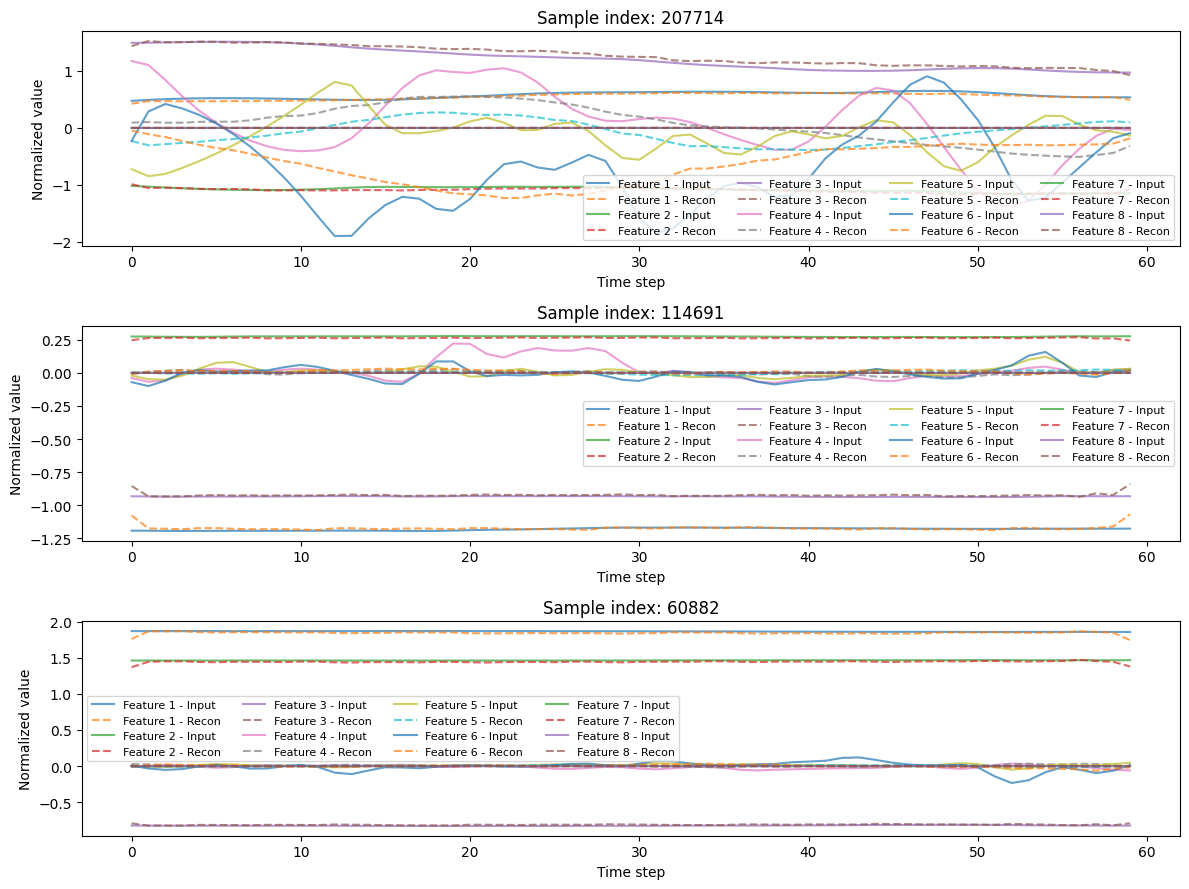

In [8]:
# =====================================================
# VISUALIZE INPUT vs RECONSTRUCTION FOR A FEW SAMPLES
# =====================================================
import random

# Load best model
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

# Pick random sample indices
num_samples = 3
indices = random.sample(range(len(full_dataset)), num_samples)

fig, axes = plt.subplots(num_samples, 1, figsize=(12, 3 * num_samples))

if num_samples == 1:
    axes = [axes]  # ensure iterable

for ax, idx in zip(axes, indices):
    inp = full_dataset[idx].unsqueeze(0).to(DEVICE)  # (1, 8, 60)
    with torch.no_grad():
        out, _ = model(inp)

    inp = inp.squeeze(0).cpu().numpy()   # (8, 60)
    out = out.squeeze(0).cpu().numpy()   # (8, 60)

    # Plot all features
    for feat in range(inp.shape[0]):
        ax.plot(inp[feat], label=f"Feature {feat+1} - Input", alpha=0.7)
        ax.plot(out[feat], '--', label=f"Feature {feat+1} - Recon", alpha=0.7)

    ax.set_title(f"Sample index: {idx}")
    ax.legend(ncol=4, fontsize=8)
    ax.set_xlabel("Time step")
    ax.set_ylabel("Normalized value")

plt.tight_layout()
plt.show()


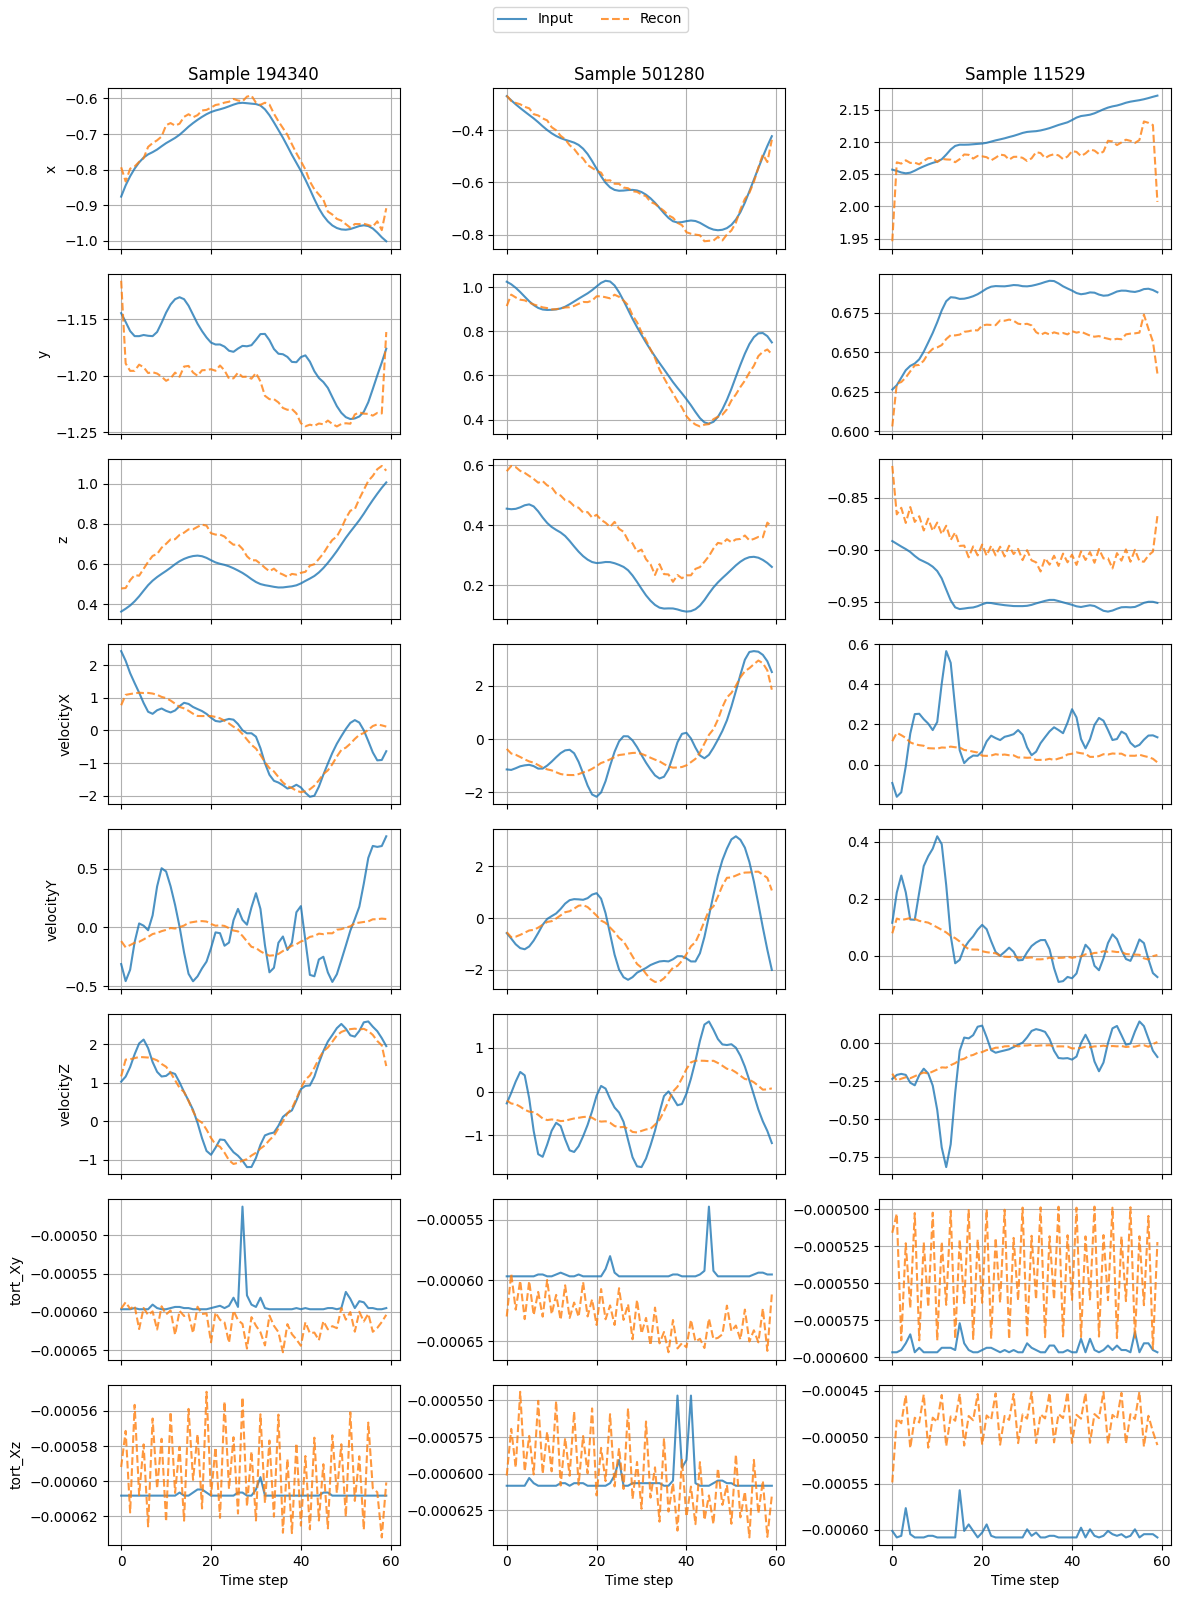

In [9]:
# =====================================================
# VISUALIZE INPUT vs RECONSTRUCTION - FEATURE-WISE
# =====================================================
import random
import matplotlib.pyplot as plt
import torch

# Load best model
model.load_state_dict(torch.load("best_model.pth", map_location=DEVICE))
model.eval()

# Pick random sample indices
num_samples = 3
indices = random.sample(range(len(full_dataset)), num_samples)

feature_names = ['x', 'y', 'z', 'velocityX', 'velocityY', 'velocityZ', 'tort_Xy', 'tort_Xz']

fig, axes = plt.subplots(8, num_samples, figsize=(4 * num_samples, 16), sharex=True)

if num_samples == 1:
    axes = axes.reshape(-1, 1)  # Ensure 2D array for consistent indexing

for col, idx in enumerate(indices):
    inp = full_dataset[idx].unsqueeze(0).to(DEVICE)  # (1, 8, 60)
    with torch.no_grad():
        out, _ = model(inp)

    inp = inp.squeeze(0).cpu().numpy()   # (8, 60)
    out = out.squeeze(0).cpu().numpy()   # (8, 60)

    for feat in range(inp.shape[0]):
        ax = axes[feat, col]
        ax.plot(inp[feat], label="Input", alpha=0.8)
        ax.plot(out[feat], '--', label="Recon", alpha=0.8)
        if col == 0:
            ax.set_ylabel(feature_names[feat])
        if feat == 0:
            ax.set_title(f"Sample {idx}")
        ax.grid(True)
        if feat == inp.shape[0] - 1:
            ax.set_xlabel("Time step")

# Add legend only once
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


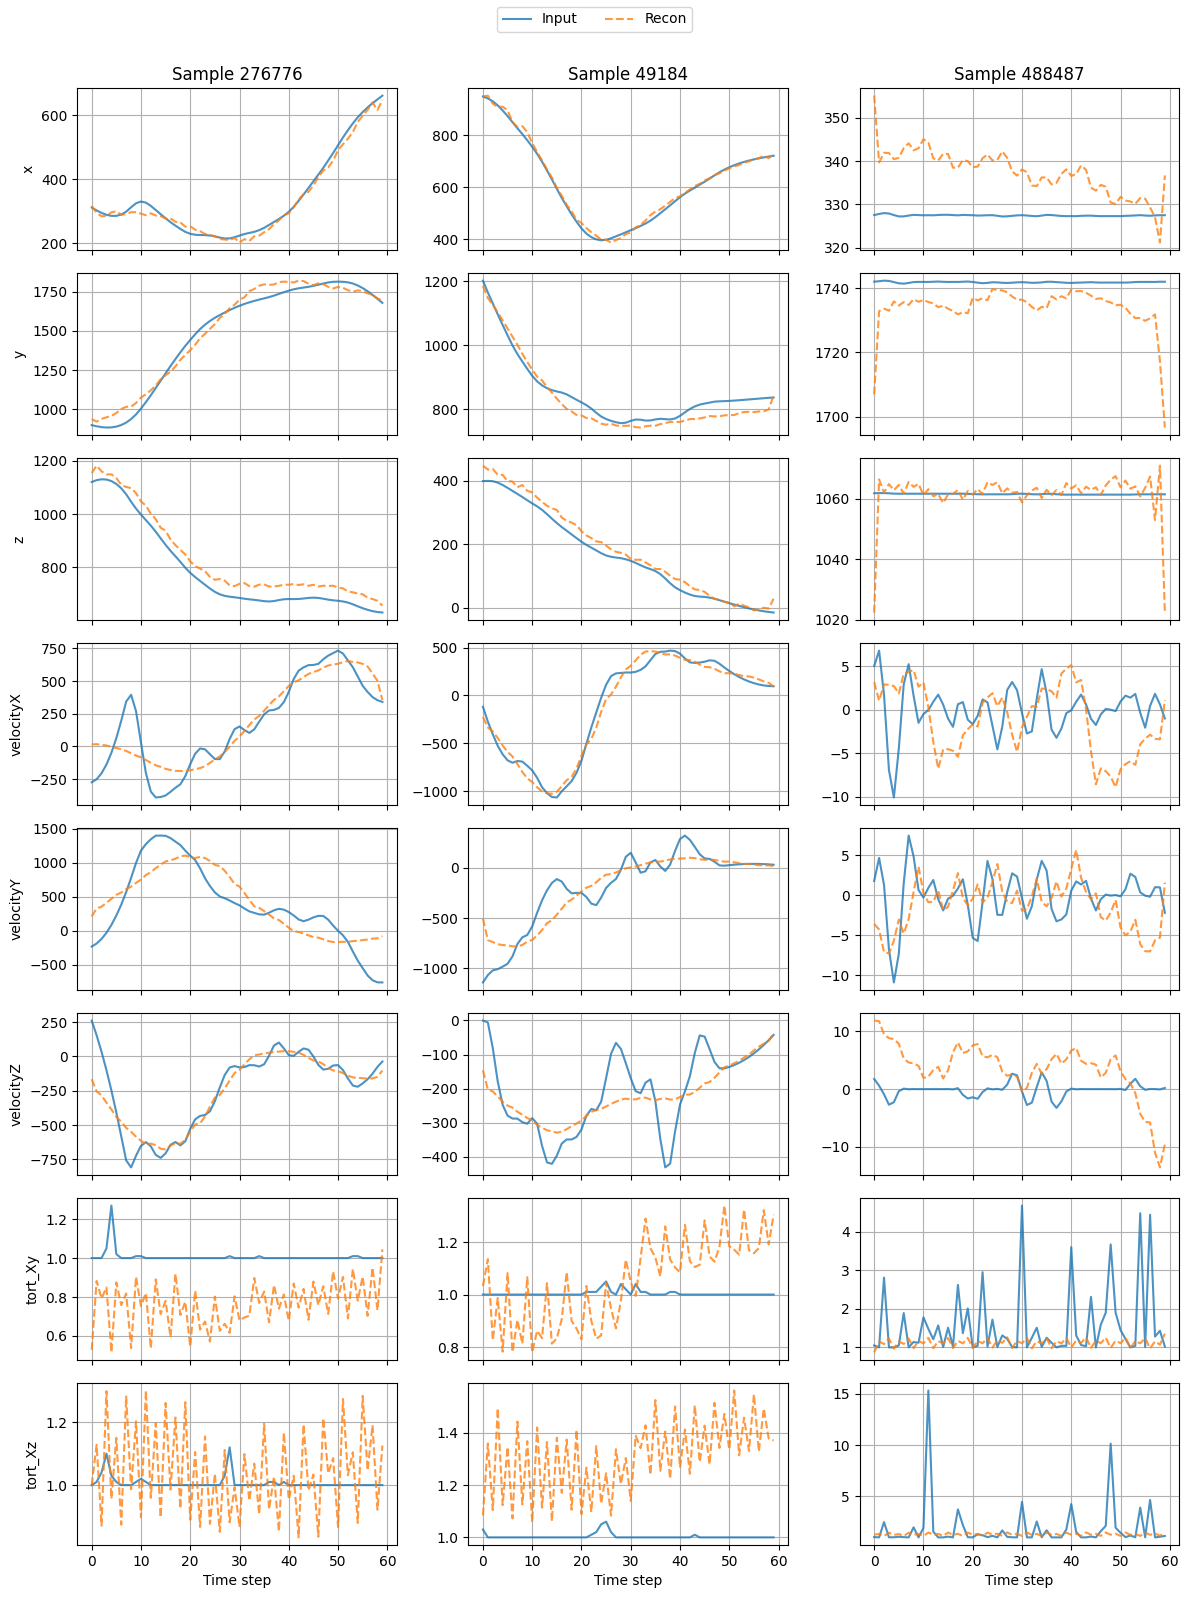

In [10]:
import random
import matplotlib.pyplot as plt
import torch

# Load normalization stats
import pickle
with open("bee_norm_stats.pkl", "rb") as f:
    norm_stats = pickle.load(f)
means = norm_stats["mean"]  # shape: (8,)
stds  = norm_stats["std"]   # shape: (8,)

feature_names = ['x', 'y', 'z', 'velocityX', 'velocityY', 'velocityZ', 'tort_Xy', 'tort_Xz']

# Load best model
model.load_state_dict(torch.load("best_model.pth", map_location=DEVICE))
model.eval()

# Pick random sample indices
num_samples = 3
indices = random.sample(range(len(full_dataset)), num_samples)

fig, axes = plt.subplots(8, num_samples, figsize=(4 * num_samples, 16), sharex=True)

if num_samples == 1:
    axes = axes.reshape(-1, 1)  # Ensure 2D array for consistent indexing

for col, idx in enumerate(indices):
    inp = full_dataset[idx].unsqueeze(0).to(DEVICE)  # normalized (1, 8, 60)
    with torch.no_grad():
        out, _ = model(inp)

    inp = inp.squeeze(0).cpu().numpy()   # (8, 60)
    out = out.squeeze(0).cpu().numpy()   # (8, 60)

    # Reverse normalization: x_orig = x_norm * std + mean
    inp_unnorm = inp * stds[:, None] + means[:, None]
    out_unnorm = out * stds[:, None] + means[:, None]

    for feat in range(inp.shape[0]):
        ax = axes[feat, col]
        ax.plot(inp_unnorm[feat], label="Input", alpha=0.8)
        ax.plot(out_unnorm[feat], '--', label="Recon", alpha=0.8)
        if col == 0:
            ax.set_ylabel(feature_names[feat])
        if feat == 0:
            ax.set_title(f"Sample {idx}")
        ax.grid(True)
        if feat == inp.shape[0] - 1:
            ax.set_xlabel("Time step")

# Add legend only once
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


-----------------------------------------------------------
k-means with elbow for 50k samples

-----------------------------------------------------------


=== STEP 1: Loading embeddings ===
[INFO] Loaded embeddings of shape (540278, 128)

=== STEP 2: Creating subset for K estimation ===
[INFO] Using subset of 50000 samples for elbow/silhouette analysis

=== STEP 3: Running Elbow & Silhouette Analysis ===
  -> Fitting MiniBatchKMeans for k=2 ... done in 31.58s | inertia=341234.47, silhouette=0.1525
  -> Fitting MiniBatchKMeans for k=3 ... done in 29.32s | inertia=317406.84, silhouette=0.1356
  -> Fitting MiniBatchKMeans for k=4 ... done in 28.78s | inertia=297159.62, silhouette=0.1497
  -> Fitting MiniBatchKMeans for k=5 ... done in 28.48s | inertia=287101.50, silhouette=0.1402
  -> Fitting MiniBatchKMeans for k=6 ... done in 28.26s | inertia=275275.28, silhouette=0.1599
  -> Fitting MiniBatchKMeans for k=7 ... done in 28.00s | inertia=267043.72, silhouette=0.1512
  -> Fitting MiniBatchKMeans for k=8 ... done in 28.14s | inertia=257598.89, silhouette=0.1387
  -> Fitting MiniBatchKMeans for k=9 ... done in 28.19s | inertia=252842.36, silh

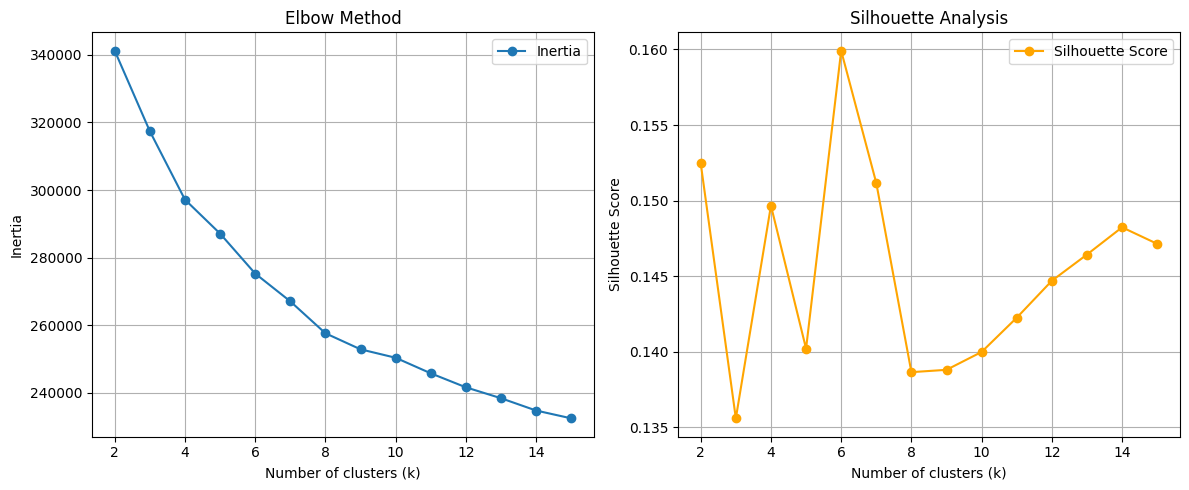


=== STEP 5: Clustering full dataset with k=8 ===
[INFO] Full dataset clustering done in 1.55s

=== STEP 6: Saving cluster labels ===
[INFO] Cluster labels saved to cluster_labels.npy with shape (540278,)

[SUMMARY] Total runtime: 401.14s


In [13]:
import torch
import numpy as np
import random
import matplotlib.pyplot as plt
import time
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

start_total = time.time()

print("\n=== STEP 1: Loading embeddings ===")
embeddings = torch.load("final_embeddings.pt")  # shape: (N, bottleneck_dim)
embeddings_np = embeddings.numpy()
print(f"[INFO] Loaded embeddings of shape {embeddings_np.shape}")

# =====================================================
# SUBSAMPLE FOR K ESTIMATION
# =====================================================
print("\n=== STEP 2: Creating subset for K estimation ===")
SAMPLE_SIZE = 50000
subset_idx = np.random.choice(len(embeddings_np), size=SAMPLE_SIZE, replace=False)
subset_embeddings = embeddings_np[subset_idx]
print(f"[INFO] Using subset of {SAMPLE_SIZE} samples for elbow/silhouette analysis")

# =====================================================
# ELBOW & SILHOUETTE METHOD
# =====================================================
print("\n=== STEP 3: Running Elbow & Silhouette Analysis ===")
k_values = range(2, 16)
inertia_scores = []
silhouette_scores = []

start_analysis = time.time()
for k in k_values:
    step_start = time.time()
    print(f"  -> Fitting MiniBatchKMeans for k={k} ...", end=" ", flush=True)
    
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1024)
    kmeans.fit(subset_embeddings)
    inertia_scores.append(kmeans.inertia_)
    
    sil_score = silhouette_score(subset_embeddings, kmeans.labels_)
    silhouette_scores.append(sil_score)
    
    print(f"done in {time.time()-step_start:.2f}s | inertia={inertia_scores[-1]:.2f}, silhouette={sil_score:.4f}")

print(f"[INFO] Elbow & Silhouette analysis completed in {time.time()-start_analysis:.2f}s")

# =====================================================
# PLOT RESULTS
# =====================================================
print("\n=== STEP 4: Plotting results ===")
plt.figure(figsize=(12,5))

# Elbow plot
plt.subplot(1, 2, 1)
plt.plot(k_values, inertia_scores, 'o-', label='Inertia')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid()
plt.legend()

# Silhouette plot
plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, 'o-', color='orange', label='Silhouette Score')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

# =====================================================
# CHOOSE K AND CLUSTER FULL DATA
# =====================================================
BEST_K = 8  # <-- change after inspecting plots
print(f"\n=== STEP 5: Clustering full dataset with k={BEST_K} ===")
start_full = time.time()
final_kmeans = MiniBatchKMeans(n_clusters=BEST_K, random_state=42, batch_size=2048)
cluster_labels = final_kmeans.fit_predict(embeddings_np)
print(f"[INFO] Full dataset clustering done in {time.time()-start_full:.2f}s")

# =====================================================
# SAVE LABELS
# =====================================================
print("\n=== STEP 6: Saving cluster labels ===")
np.save("cluster_labels.npy", cluster_labels)
print(f"[INFO] Cluster labels saved to cluster_labels.npy with shape {cluster_labels.shape}")

# =====================================================
# RUNTIME SUMMARY
# =====================================================
print(f"\n[SUMMARY] Total runtime: {time.time()-start_total:.2f}s")


In [16]:
import torch
import numpy as np
import pickle
import pandas as pd
import time
from sklearn.cluster import MiniBatchKMeans

# ----------------------------
# STEP 1: Load embeddings
# ----------------------------
start_total = time.time()
print("\n=== STEP 1: Loading embeddings ===")
embeddings = torch.load("final_embeddings.pt")  # shape: (540278, bottleneck_dim)
embeddings_np = embeddings.numpy()
print(f"[INFO] Loaded embeddings of shape {embeddings_np.shape}")

# ----------------------------
# STEP 2: Cluster full dataset
# ----------------------------
BEST_K = 6
print(f"\n=== STEP 2: Clustering full dataset with k={BEST_K} ===")
start_cluster = time.time()
kmeans = MiniBatchKMeans(n_clusters=BEST_K, random_state=42, batch_size=2048)
cluster_labels = kmeans.fit_predict(embeddings_np)
print(f"[INFO] Clustering completed in {time.time() - start_cluster:.2f}s")

# ----------------------------
# STEP 3: Cluster statistics
# ----------------------------
print("\n=== STEP 3: Cluster statistics ===")
unique, counts = np.unique(cluster_labels, return_counts=True)
total_points = len(cluster_labels)

for lbl, cnt in zip(unique, counts):
    perc = (cnt / total_points) * 100
    print(f"Cluster {lbl}: {cnt} samples ({perc:.2f}%)")

# ----------------------------
# STEP 4: Load bee IDs
# ----------------------------
print("\n=== STEP 4: Loading bee IDs ===")
with open("bee_samples_with_ids.pkl", "rb") as f:
    data_dict = pickle.load(f)
bee_ids = np.array(data_dict["bee_ids"])  # Assuming "ids" holds bee IDs

if len(bee_ids) != len(cluster_labels):
    raise ValueError(f"Length mismatch: {len(bee_ids)} IDs vs {len(cluster_labels)} cluster labels")

# ----------------------------
# STEP 5: Save mapping CSV
# ----------------------------
print("\n=== STEP 5: Saving cluster-bee mapping CSV ===")
df_map = pd.DataFrame({
    "sample_index": np.arange(len(cluster_labels)),
    "bee_id": bee_ids,
    "cluster_id": cluster_labels
})
df_map.to_csv("bee_cluster_map.csv", index=False)
print(f"[INFO] Mapping saved to bee_cluster_map.csv with shape {df_map.shape}")

# ----------------------------
# SUMMARY
# ----------------------------
print(f"\n[SUMMARY] Total runtime: {time.time() - start_total:.2f}s")



=== STEP 1: Loading embeddings ===
[INFO] Loaded embeddings of shape (540278, 128)

=== STEP 2: Clustering full dataset with k=6 ===
[INFO] Clustering completed in 1.40s

=== STEP 3: Cluster statistics ===
Cluster 0: 111197 samples (20.58%)
Cluster 1: 73579 samples (13.62%)
Cluster 2: 109577 samples (20.28%)
Cluster 3: 135709 samples (25.12%)
Cluster 4: 80595 samples (14.92%)
Cluster 5: 29621 samples (5.48%)

=== STEP 4: Loading bee IDs ===

=== STEP 5: Saving cluster-bee mapping CSV ===
[INFO] Mapping saved to bee_cluster_map.csv with shape (540278, 3)

[SUMMARY] Total runtime: 4.22s


[INFO] Selected bees for plotting: ['Bee1', 'Bee9', 'Bee35']


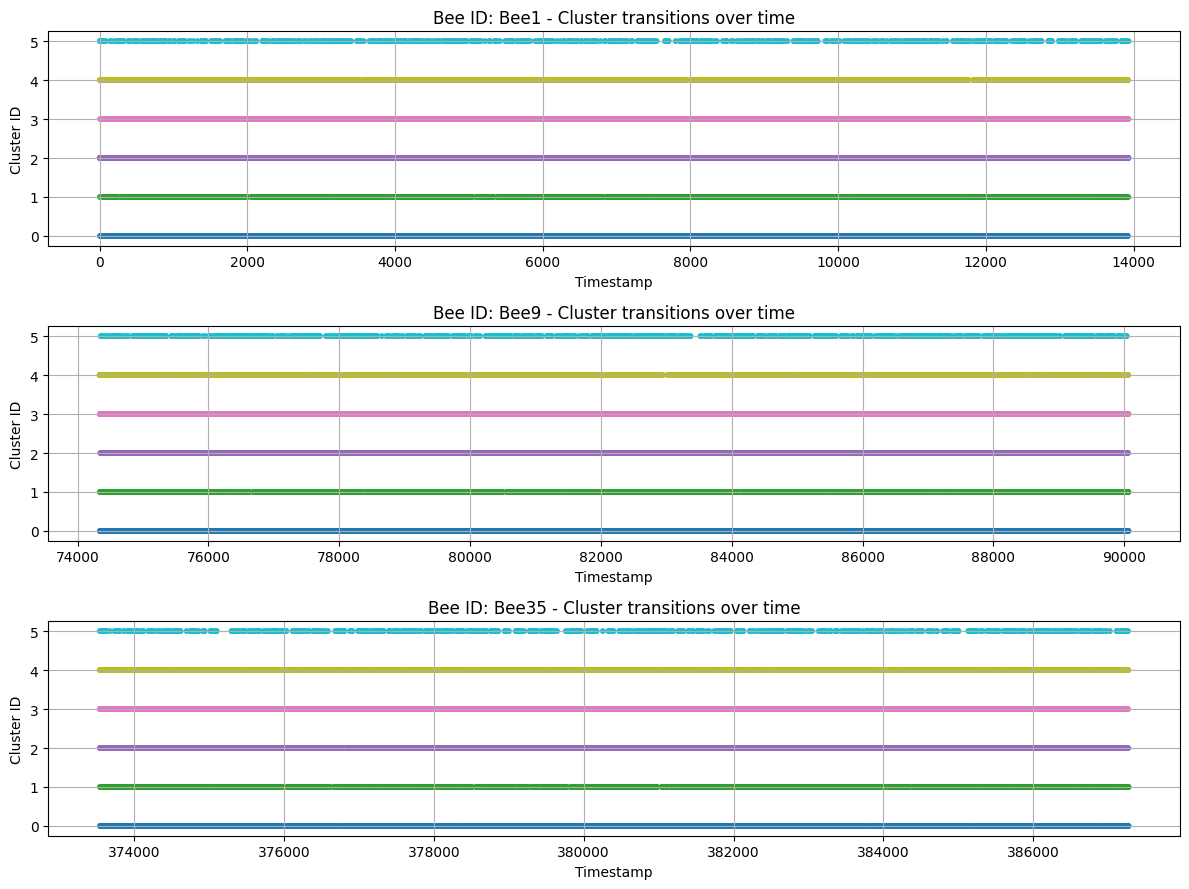

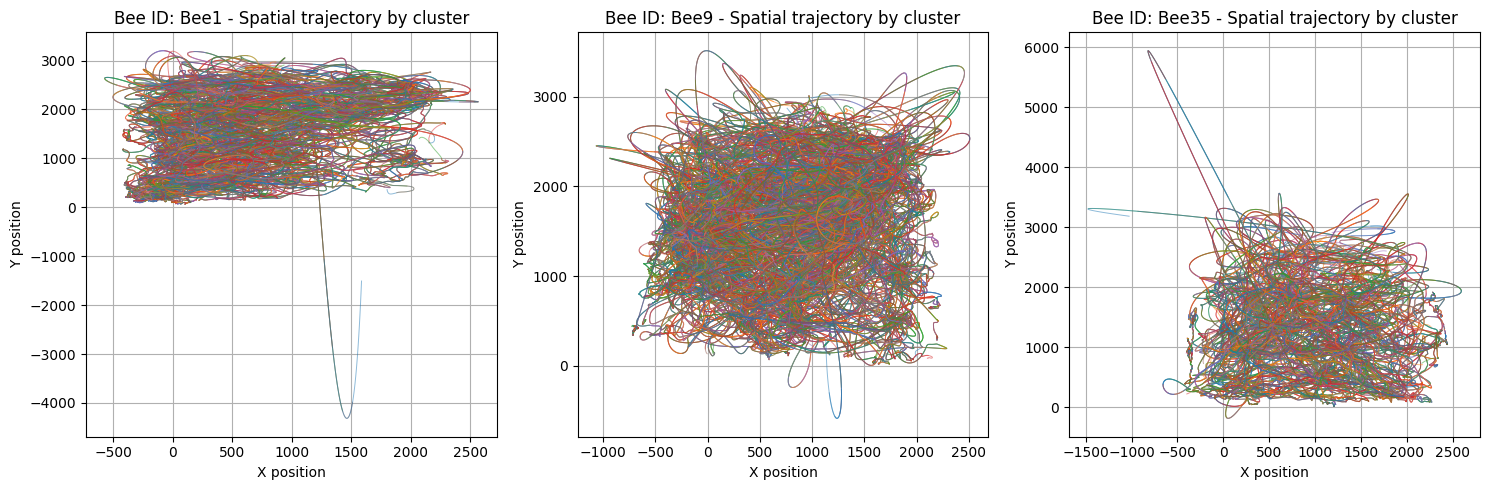

In [19]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

# -----------------------------------------
# Load cluster map
# -----------------------------------------
df_map = pd.read_csv("bee_cluster_map.csv")

# -----------------------------------------
# Load original data
# -----------------------------------------
with open("bee_samples_with_ids.pkl", "rb") as f:
    data_dict = pickle.load(f)

segments = np.array(data_dict["segments"])  # shape: (N, 8, 60)
bee_ids = np.array(data_dict["bee_ids"])        # shape: (N,)
timestamps = np.array(data_dict.get("timestamps", np.arange(len(bee_ids))))  # fallback to index order

df_map["timestamp"] = timestamps

# -----------------------------------------
# Pick a few bees for plotting
# -----------------------------------------
num_bees_to_plot = 3
unique_bees = df_map["bee_id"].unique()
selected_bees = random.sample(list(unique_bees), num_bees_to_plot)
print(f"[INFO] Selected bees for plotting: {selected_bees}")

# -----------------------------------------
# 1. Timeline plots
# -----------------------------------------
fig, axes = plt.subplots(num_bees_to_plot, 1, figsize=(12, 3*num_bees_to_plot), sharex=False)

if num_bees_to_plot == 1:
    axes = [axes]  # make iterable

for ax, bee in zip(axes, selected_bees):
    bee_data = df_map[df_map["bee_id"] == bee].sort_values("timestamp")
    ax.scatter(bee_data["timestamp"], bee_data["cluster_id"], c=bee_data["cluster_id"], cmap="tab10", s=10)
    ax.set_title(f"Bee ID: {bee} - Cluster transitions over time")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Cluster ID")
    ax.grid(True)

plt.tight_layout()
plt.show()

# -----------------------------------------
# 2. Spatial trajectory plots (full 60 steps per segment)
# -----------------------------------------
fig, axes = plt.subplots(1, num_bees_to_plot, figsize=(5*num_bees_to_plot, 5), sharex=False, sharey=False)

if num_bees_to_plot == 1:
    axes = [axes]

for ax, bee in zip(axes, selected_bees):
    bee_indices = np.where(df_map["bee_id"] == bee)[0]

    for idx in bee_indices:
        cluster_id = df_map.iloc[idx]["cluster_id"]
        x_traj = segments[idx, 0, :]  # all 60 timesteps x
        y_traj = segments[idx, 1, :]  # all 60 timesteps y
        ax.plot(x_traj, y_traj, color=plt.cm.tab10(cluster_id), alpha=0.5, linewidth=0.7)

    ax.set_title(f"Bee ID: {bee} - Spatial trajectory by cluster")
    ax.set_xlabel("X position")
    ax.set_ylabel("Y position")
    ax.grid(True)

plt.tight_layout()
plt.show()


[INFO] Selected bees for plotting: ['Bee34', 'Bee49', 'Bee33']


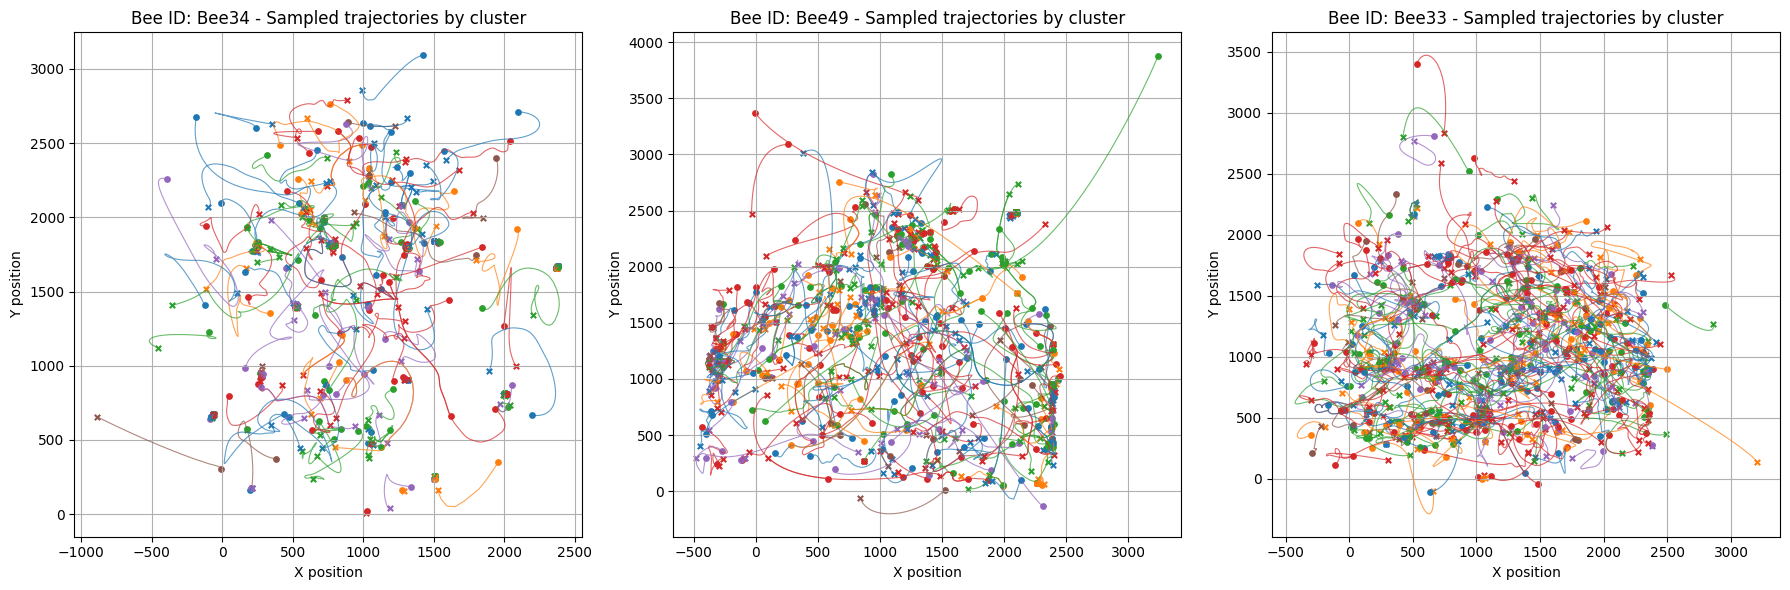

In [21]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

# -----------------------------------------
# Load cluster mapping
# -----------------------------------------
df_map = pd.read_csv("bee_cluster_map.csv")

# -----------------------------------------
# Load original data
# -----------------------------------------
with open("bee_samples_with_ids.pkl", "rb") as f:
    data_dict = pickle.load(f)

segments = np.array(data_dict["segments"])  # shape: (N, 8, 60)
bee_ids = np.array(data_dict["bee_ids"])        # shape: (N,)
timestamps = np.array(data_dict.get("timestamps", np.arange(len(bee_ids))))

df_map["timestamp"] = timestamps

# -----------------------------------------
# Settings
# -----------------------------------------
MAX_SEGMENTS_PER_BEE = 400
num_bees_to_plot = 3
cmap = plt.cm.tab10

# Pick random bees
unique_bees = df_map["bee_id"].unique()
selected_bees = random.sample(list(unique_bees), num_bees_to_plot)
print(f"[INFO] Selected bees for plotting: {selected_bees}")

# -----------------------------------------
# Plot
# -----------------------------------------
fig, axes = plt.subplots(1, num_bees_to_plot, figsize=(6*num_bees_to_plot, 6), sharex=False, sharey=False)

if num_bees_to_plot == 1:
    axes = [axes]

for ax, bee in zip(axes, selected_bees):
    bee_indices = np.where(df_map["bee_id"] == bee)[0]

    # Subsample to reduce clutter
    if len(bee_indices) > MAX_SEGMENTS_PER_BEE:
        bee_indices = np.random.choice(bee_indices, MAX_SEGMENTS_PER_BEE, replace=False)

    for idx in bee_indices:
        cluster_id = df_map.iloc[idx]["cluster_id"]
        x_traj = segments[idx, 0, :]
        y_traj = segments[idx, 1, :]

        # Plot trajectory with arrow to show direction
        ax.plot(x_traj, y_traj, color=cmap(cluster_id), alpha=0.7, linewidth=0.8)
        ax.scatter(x_traj[0], y_traj[0], color=cmap(cluster_id), marker="o", s=15)  # Start
        ax.scatter(x_traj[-1], y_traj[-1], color=cmap(cluster_id), marker="x", s=15) # End

    ax.set_title(f"Bee ID: {bee} - Sampled trajectories by cluster")
    ax.set_xlabel("X position")
    ax.set_ylabel("Y position")
    ax.grid(True)

plt.tight_layout()
plt.show()


Visualising clustered behaviours
We can sweep through the entire trajectory for each bee, providing short segments of the trajectory to the NN as inputs, obtaining the hidden/output layer representation, determining the cluster (i.e. behavioural motif) to which the representation belongs, and assigning that behaviour a colour. Following this method, we can assign a cluster (behavioural motif) to every time point in the trajectory, and plot it using the colour codes, to visualise how one behaviour transitions into another, and into yet another, during the entire recording of that bee.

-----------------------------------------------------------------------
